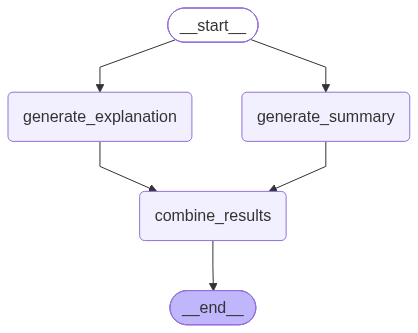


    Topic: Artificial Intelligence
    Summary:
    **Summary of Artificial Intelligence (AI):**

Artificial Intelligence (AI) is a branch of computer science focused on creating systems that can perform tasks requiring human-like intelligence, such as reasoning, learning, problem-solving, and decision-making. AI enables machines to adapt, improve, and function autonomously or with minimal human input.

Key aspects include:
- **Machine Learning (ML):** AI models learn from data to make predictions or decisions.
- **Natural Language Processing (NLP):** AI interprets and generates human language (e.g., chatbots, translation tools).
- **Computer Vision:** AI analyzes and interprets visual data (e.g., facial recognition, medical imaging).
- **Robotics & Automation:** AI powers self-driving cars, industrial robots, and smart assistants.

AI has applications in healthcare, finance, transportation, and daily life, but also raises ethical concerns like bias, privacy, and job displacement. Adv

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

load_dotenv()

llm = ChatMistralAI(model="ministral-3b-latest")

class State(TypedDict):
    topic: str
    summary: str
    explanation: str
    final_output: str

def generate_summary(state: State):
    prompt = f"""
    Give a short summary of the following topic:
    {state['topic']}
    """
    response = llm.invoke(prompt)
    return {"summary": response.content}

def generate_explanation(state: State):
    prompt = f"""
    Explain the following topic in simple terms for a beginner:
    {state['topic']}
    """
    response = llm.invoke(prompt)
    return {"explanation": response.content}

def combine_results(state: State):
    final_output = f"""
    Topic: {state['topic']}
    Summary:
    {state['summary']}
    Explanation:
    {state['explanation']}
    """
    return {"final_output": final_output}

graph = StateGraph(State)

graph.add_node("generate_summary", generate_summary)
graph.add_node("generate_explanation", generate_explanation)
graph.add_node("combine_results", combine_results)

graph.add_edge(START, "generate_summary")
graph.add_edge(START, "generate_explanation")
graph.add_edge("generate_summary", "combine_results")
graph.add_edge("generate_explanation", "combine_results")
graph.add_edge("combine_results", END)

workflow = graph.compile()

result = workflow.invoke({"topic": "Artificial Intelligence",})

from IPython.display import display, Image
display(Image(workflow.get_graph().draw_mermaid_png()))

print(result["final_output"])